In [21]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
import h5py

In [16]:
# optional aesthetics
viennared = "#DA0A14"

rc_params = {
    'axes.grid': False,
    'axes.labelsize': 24,
    'axes.linewidth':1.75,
    'axes.titlesize': 32,
    'font.size': 24,
    'legend.fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
    # If you have latex installed, set to true. Otherwise, keep this set to false
    'text.usetex':True,
    'patch.force_edgecolor':True,
}a
plt.rcParams.update(rc_params)

# Utility Functions

# Load NR Scattering Data

In [128]:
# We have provided a HDF5 file containing the NR scattering trajectories
nr_file = h5py.File('data/scatter_q_1p00_c1_0p00_c2_0p00_PADM_0p11456_bNR_10p00.h5', 'r')

In [129]:
# The h5 file provides the following parameters
nr_file.keys()

<KeysViewHDF5 ['PADM', 'initial-ADM-angular-momentum', 'initial-ADM-energy', 'initial-ADM-linear-momentum', 'initial-angular-momentum', 'initial-angular-momentum_x', 'initial-angular-momentum_y', 'initial-angular-momentum_z', 'initial-linear-momentum-bh1', 'initial-linear-momentum-bh1_x', 'initial-linear-momentum-bh1_y', 'initial-linear-momentum-bh1_z', 'initial-linear-momentum-bh2', 'initial-linear-momentum-bh2_x', 'initial-linear-momentum-bh2_y', 'initial-linear-momentum-bh2_z', 'initial-mass-bh1', 'initial-mass-bh2', 'initial-position-bh1', 'initial-position-bh2', 'initial-separation', 'initial-spin-bh1', 'initial-spin-bh1x', 'initial-spin-bh1y', 'initial-spin-bh1z', 'initial-spin-bh2', 'initial-spin-bh2x', 'initial-spin-bh2y', 'initial-spin-bh2z', 'px1', 'px2', 'py1', 'py2', 'pz1', 'pz2', 'r1', 'r2', 'tag', 'times', 'vx1', 'vx2', 'vy1', 'vy2', 'vz1', 'vz2', 'x1', 'x2', 'y1', 'y2', 'z1', 'z2']>

In [130]:
# Let's get the initial ADM energy and angular momentum (as spins are 0, J = L)
E_ADM = np.around(nr_file['initial-ADM-energy'][()],5)
L_ADM = np.around(nr_file['initial-ADM-angular-momentum'][()],4)
print('E_ADM : ', E_ADM)
print('L_ADM : ', L_ADM)

E_ADM :  1.02264
L_ADM :  1.1456


In [131]:
# Cartesian coordinates of each black hole and the common times
x1 = nr_file['x1'][()]
x2 = nr_file['x2'][()]
y1 = nr_file['y1'][()]
y2 = nr_file['y2'][()]
z1 = nr_file['z1'][()]
z2 = nr_file['z2'][()]
t  = nr_file['times'][()]

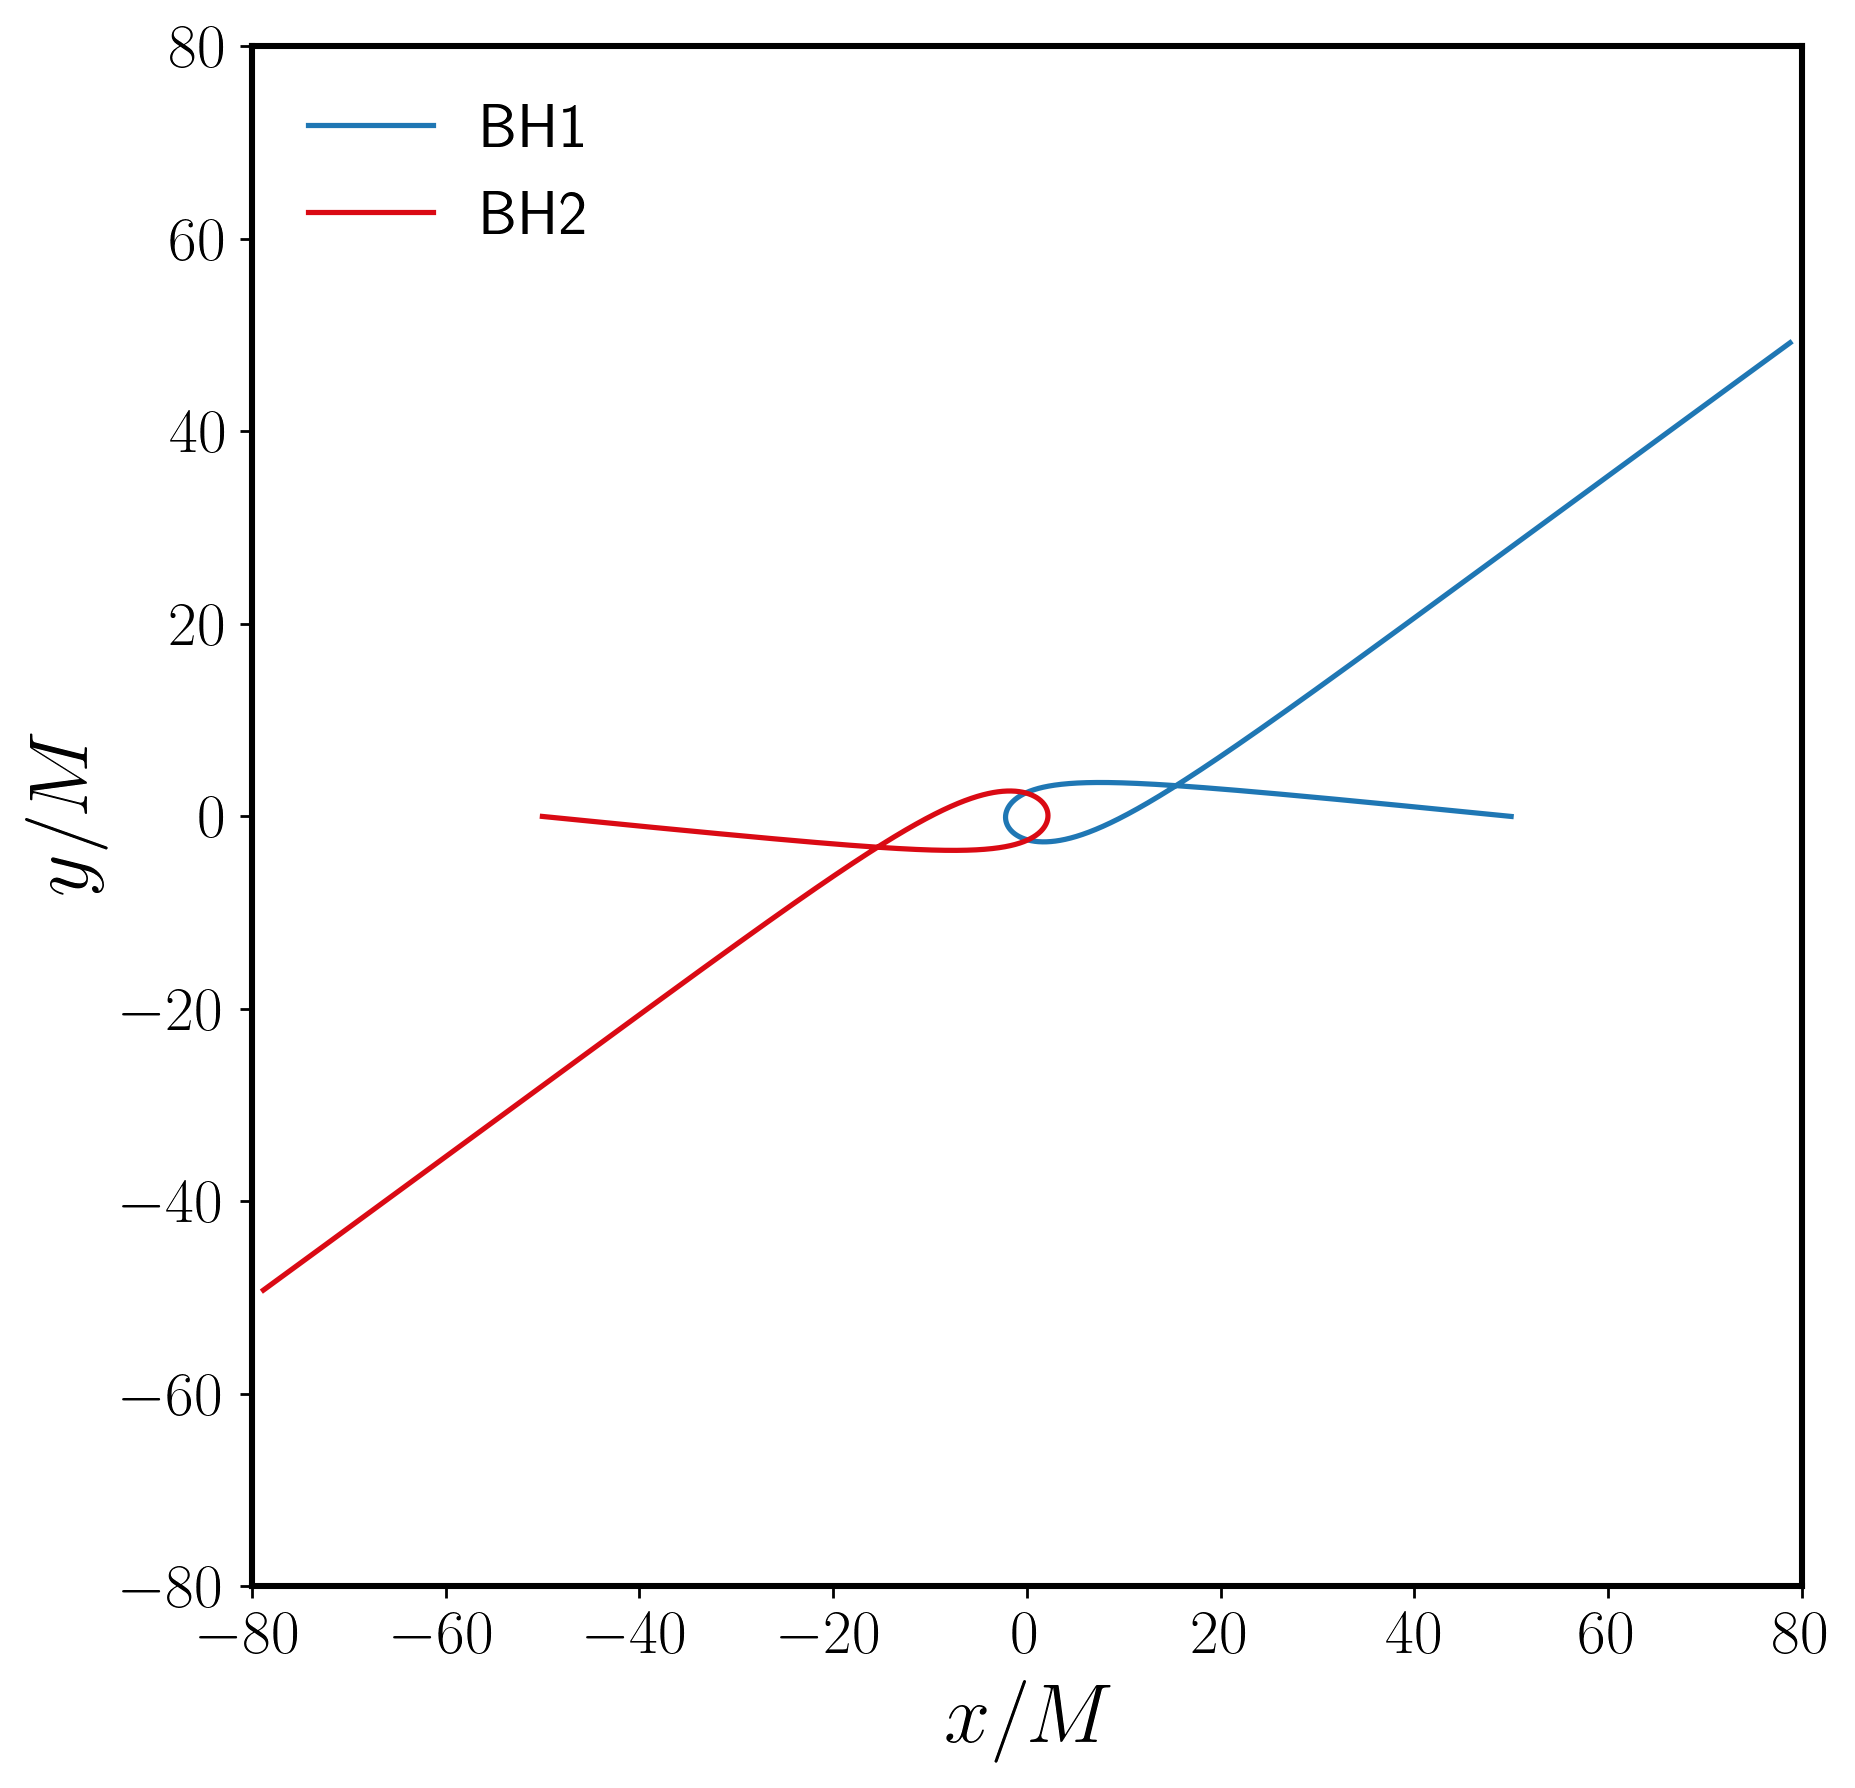

In [158]:
# Plot scattering motion
plt.figure(dpi=250, figsize=(8,8))
plt.plot(x1,y1, label='BH1');
plt.plot(x2,y2, c=viennared, label='BH2');
plt.xlabel(r'$x/M$');
plt.ylabel(r'$y/M$');
plt.legend(loc='upper left', frameon=False);
plt.xlim(-80,80);
plt.ylim(-80,80);

## Task

- Calculate the Cartesian motion to polar coordinates $(r, \theta)$
- Create a routine to extrapolate the scattering angles to infinity, i.e. $r \rightarrow \infty$ or equivalently $u = (1/r) \rightarrow 0$
- Calculate the scattering angle for 2D planar motion:

$\theta_i = \varphi_{\mathrm{out},i}^{\infty} - \varphi_{\mathrm{in},i}^{\infty} - \pi$

# NR Data from 

In [65]:
nr_datatable = {
    "b_NR": [
        9.40, 9.50, 9.55, 9.56, 9.57, 9.58, 9.60, 9.70, 9.90,
        10.00, 10.20, 10.40, 11.00, 12.00, 13.00, 14.00, 15.00, 16.00
    ],
    "E_ADM_in": [
        1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264,
        1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264, 1.02264
    ],
    "L_ADM_in": [
        1.07690, 1.08840, 1.09410, 1.09520, 1.09640, 1.09750, 1.09980, 1.11130, 1.13420,
        1.14560, 1.16860, 1.19150, 1.26020, 1.37480, 1.48930, 1.60390, 1.71850, 1.83300
    ],
    "theta_NR_deg": [None, 376.275, 329.057, 323.422, 318.394, 313.764, 305.734, 274.368, 235.447, 221.823, 200.810, 184.684, 152.106, 120.804, 101.616, 88.260, 78.296, 70.404
    ]
}

In [69]:
def get_chi_from_L(L_ADM, data):
    Ls   = np.asarray(data["L_ADM_in"], dtype=float)
    chis = np.asarray(
        [np.nan if v is None else float(v) for v in data["theta_NR_deg"]],
        dtype=float
    )

    idx = np.where(np.isclose(Ls, L_ADM, rtol=0.0, atol=1e-8))[0]
    if len(idx) == 0:
        raise ValueError("L_ADM not found exactly in table")
    
    chi = chis[idx[0]]
    if np.isnan(chi):
        return None

    return chi

# Comparison to TEOBResumS

It is important to note that the strong-field scattering angles are sensitive to the physics in the EOB model, so EOB variants with different analytical and numerical information will give different predictions. 

Example papers:
- https://arxiv.org/abs/2307.06999
- https://arxiv.org/abs/2402.12342
- https://arxiv.org/abs/2405.20398
- https://arxiv.org/abs/2411.09652
- https://arxiv.org/abs/2508.12126

In [2]:
import EOBRun_module as EOB

In [66]:
mu        = 0.25
teob_data = {'E0': E_ADM,  'p0': L_ADM / mu }

In [70]:
teob_parameters = {
    'M'                  : 1.0,              # Total mass
    'q'                  : 1.0,              # Mass ratio m1/m2 > 1
    'chi1'               : 0.,               # Z component of chi_1
    'chi2'               : 0.,               # Z component of chi_2
    'j_hyp'              : teob_data['p0'],  # Initial angular momentum
    'H_hyp'              : teob_data['E0'],  # Initial energy
    'r_hyp'              : 100.0,            # Initial separation
    'domain'             : 0,                # Time domain. EOBSPA is not available for eccentric waveforms!
    'use_geometric_units': "yes",            # output quantities in geometric units. Default = 1
    'interp_uniform_grid': "yes",            # interpolate mode by mode on a uniform grid. Default = 0 (no interpolation)
    'use_mode_lm'        : [1],              # List of modes to use/output through EOBRunPy
    'arg_out'            : "yes",            # Output hlm/hflm. Default = 0
}

t, _, hp, _, dyn = EOB.EOBRunPy(teob_parameters)
chi_teob         = dyn['phi'][-1] - dyn['phi'][0] - np.pi
chi_teob         = np.rad2deg(chi_teob)
chi_teob         = np.around(chi_teob,3)

chi_NR           = get_chi_from_L(L_ADM, data=nr_datatable)

print('chi(NR)   : ', chi_NR) 
print('chi(EOB)  : ', chi_teob)

chi(NR)   :  221.823
chi(EOB)  :  245.936


In [150]:
def get_scattering_sequence(Ls, E = E_ADM, mu=0.25):
    teob_scattering = []
    for ll in Ls:
        jj = ll / mu
        teob_parameters = {
            'M'                  : 1.0,              # Total mass
            'q'                  : 1.0,              # Mass ratio m1/m2 > 1
            'chi1'               : 0.,               # Z component of chi_1
            'chi2'               : 0.,               # Z component of chi_2
            'j_hyp'              : jj,               # Initial angular momentum
            'H_hyp'              : E,                # Initial energy
            'r_hyp'              : 5000.0,           # Initial separation
            'domain'             : 0,                # Time domain. EOBSPA is not available for eccentric waveforms!
            'use_geometric_units': "yes",            # output quantities in geometric units. Default = 1
            'interp_uniform_grid': "yes",            # interpolate mode by mode on a uniform grid. Default = 0 (no interpolation)
            'use_mode_lm'        : [1],              # List of modes to use/output through EOBRunPy
            'arg_out'            : "yes",            # Output hlm/hflm. Default = 0
        }
        t, _, hp, _, dyn = EOB.EOBRunPy(teob_parameters)
        chi_teob         = dyn['phi'][-1] - dyn['phi'][0] - np.pi
        chi_teob         = np.rad2deg(chi_teob)
        teob_scattering.append(chi_teob)
    return teob_scattering

In [151]:
# Drop some of the early entries as these are plunging configurations, not scattering
Ls        = nr_datatable['L_ADM_in'][2:]
chis_teob = get_scattering_sequence(Ls) 
chis_nr   = nr_datatable['theta_NR_deg'][2:]

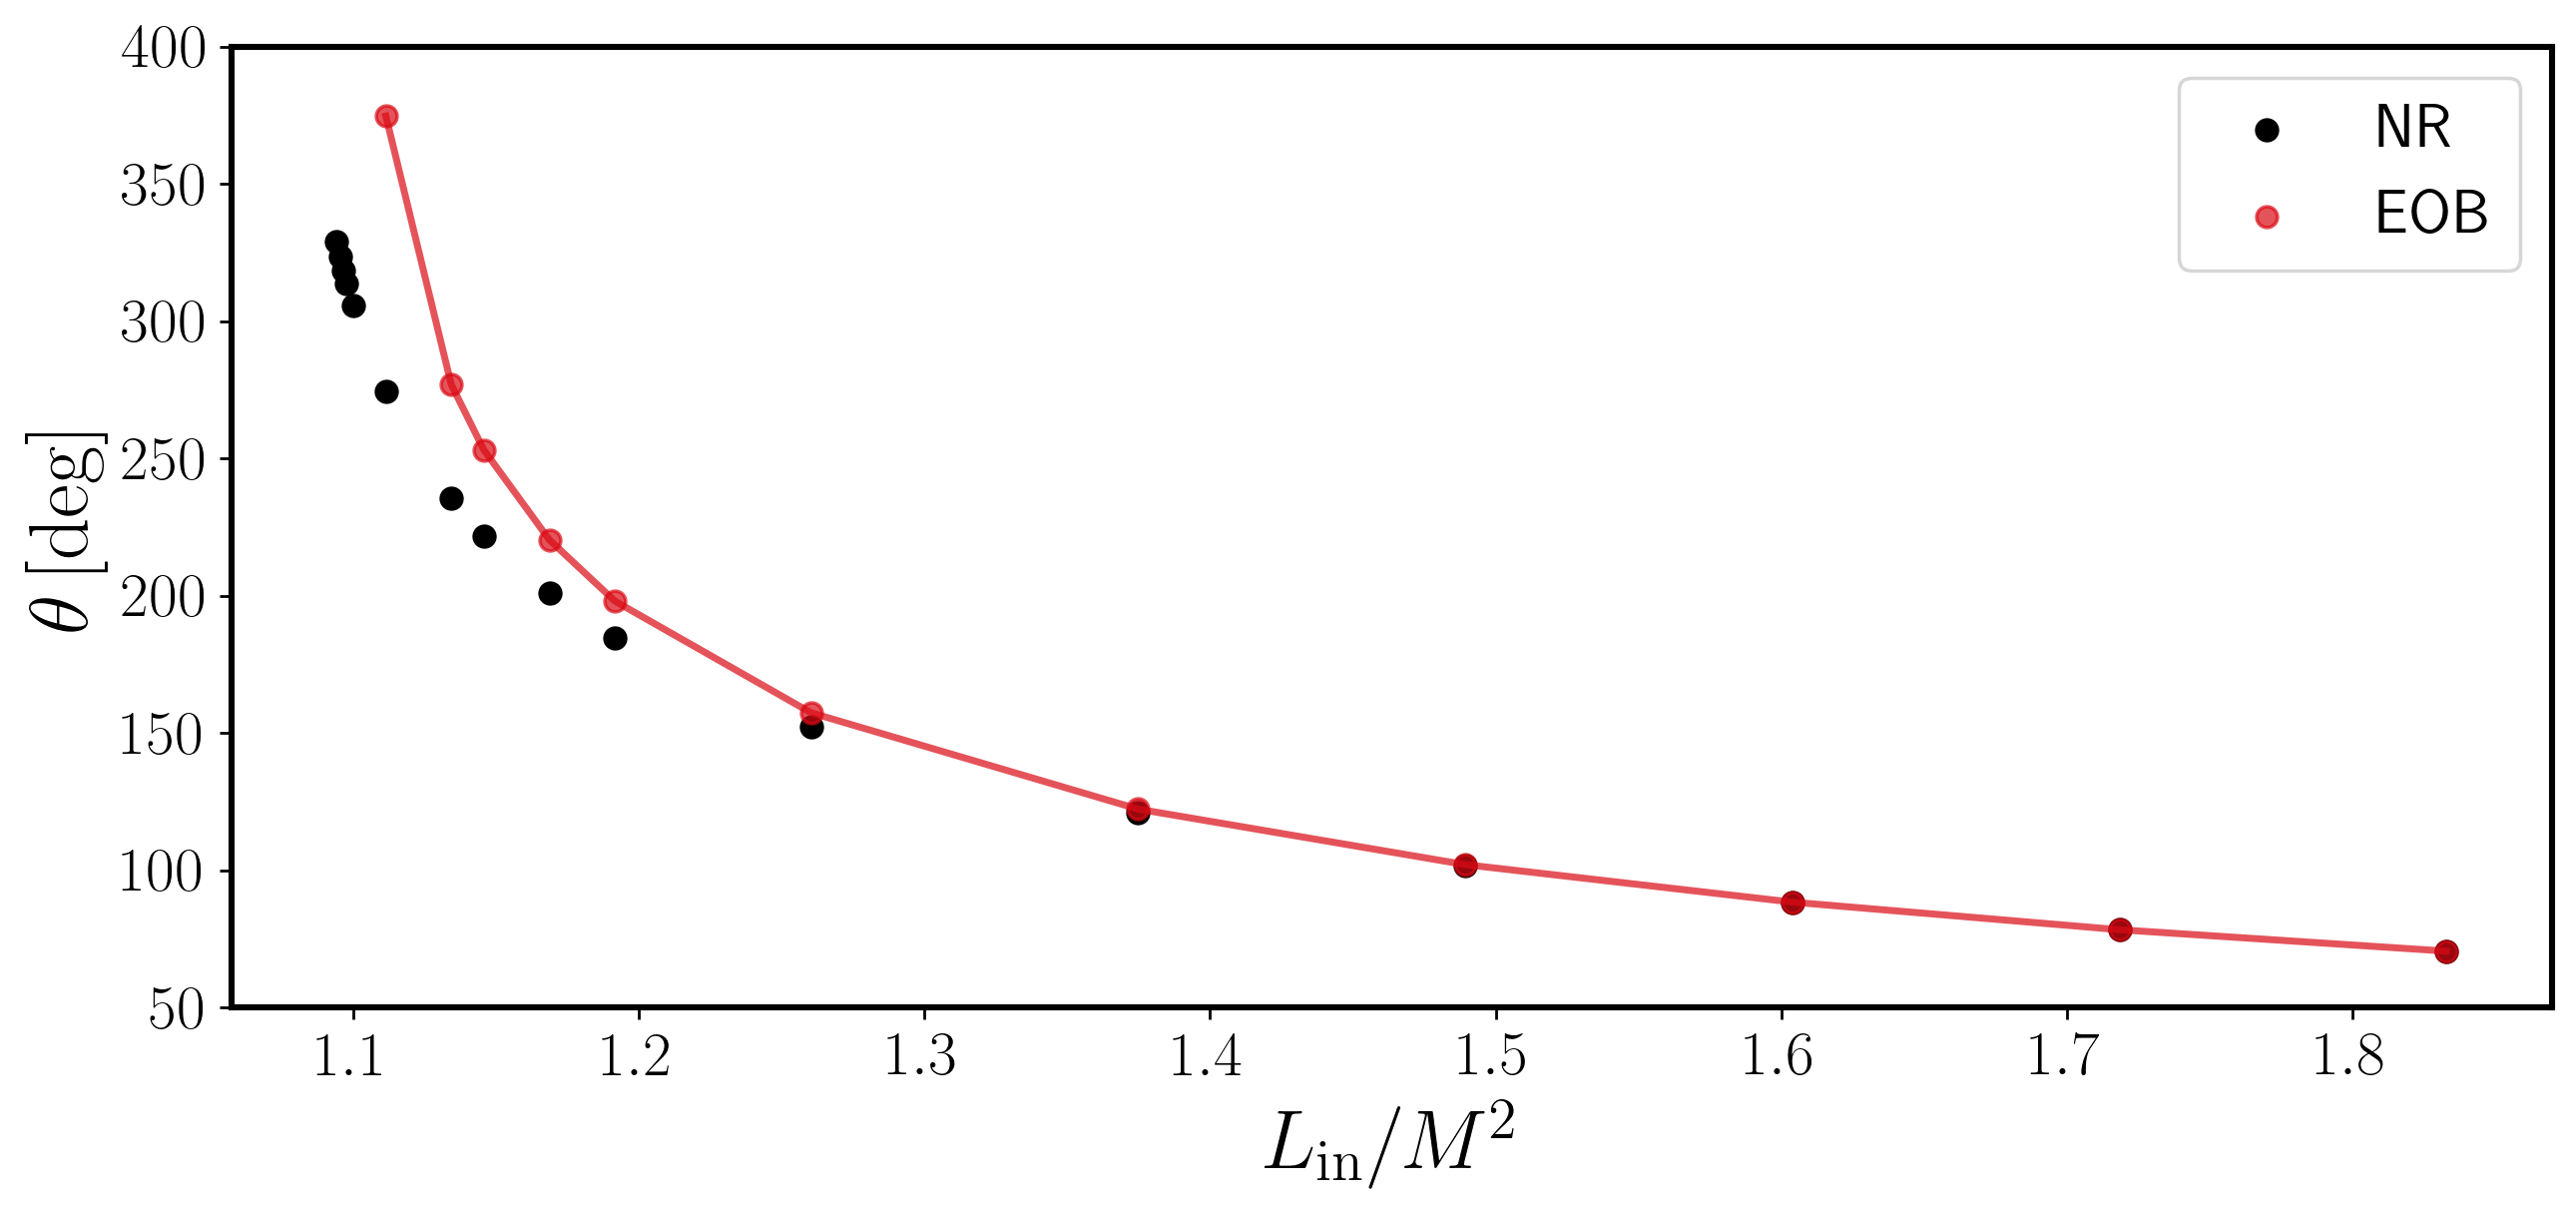

In [157]:
plt.figure(dpi=250, figsize=(12,5))
plt.scatter(Ls, chis_nr, c='k', label='NR')
# We drop the first 5 entries as they diverge relative to NR
plt.scatter(Ls[5:], chis_teob[5:], c=viennared, label='EOB', alpha=0.7)
plt.plot(Ls[5:], chis_teob[5:], c=viennared, linewidth=2, alpha=0.7)
plt.legend(loc='upper right');
plt.xlabel(r'$L_{\rm in} / M^2$');
plt.ylabel(r'$\theta \left[ \rm deg \right]$');
plt.ylim(50,400);